# Movie Recommendation System

This project implements multiple movie recommendation techniques:

- Content-Based Filtering
- Collaborative Filtering 
- Matrix Factorization (SVD)
- KNN
- Hybrid Strategy
  
Evaluation Metrics: RMSE and MAE

In [1]:
! pip install nltk

In [2]:
! pip install scikit-surprise


In [3]:
import pandas as pd
import numpy as np

In [4]:
movies = pd.read_csv("tmdb_6000_movie_dataset.csv")
credits = pd.read_csv("tmdb_6000_movie_credits.csv")
ratings = pd.read_csv("tmdb_6000_movie_ratings.csv")

In [5]:
movies.drop(columns=['Unnamed: 0'], inplace=True)
movies.head()

,budget,genres,homepage,tmdbId,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{'id': 1463, 'name': 'culture clash'}, {'id':...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{'id': 270, 'name': 'ocean'}, {'id': 726, 'na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{'id': 470, 'name': 'spy'}, {'id': 818, 'name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{'id': 849, 'name': 'dc comics'}, {'id': 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{'id': 818, 'name': 'based on novel'}, {'id':...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [6]:
movies.shape

(5798, 20)

In [7]:
credits.drop(columns=['Unnamed: 0'], inplace=True)
credits.head()

,tmdbId,cast,crew
0,19995,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [8]:
credits.shape

(5798, 3)

In [9]:
ratings.head()

,tmdbId,userId,rating,timestamp
0,19995,10.0,3.5,2015-05-03 15:28:22
1,19995,14.0,3.5,2011-07-24 18:47:52
2,19995,22.0,2.5,2019-10-14 07:22:58
3,19995,29.0,4.0,2019-02-05 20:38:13
4,19995,40.0,3.0,2016-01-06 00:50:54


In [10]:
ratings.shape

(24537619, 4)

In [11]:
df = movies.merge(credits, on = "tmdbId") #.merge(ratings, on = "tmdbId")
df.head()

,budget,genres,homepage,tmdbId,keywords,original_language,original_title,overview,popularity,production_companies,...,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{'id': 1463, 'name': 'culture clash'}, {'id':...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{'id': 270, 'name': 'ocean'}, {'id': 726, 'na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{'id': 470, 'name': 'spy'}, {'id': 818, 'name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{'id': 849, 'name': 'dc comics'}, {'id': 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{'id': 818, 'name': 'based on novel'}, {'id':...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [12]:
df.shape

(5798, 22)

In [13]:
df.columns

Index(['budget', 'genres', 'homepage', 'tmdbId', 'keywords',
       'original_language', 'original_title', 'overview', 'popularity',
       'production_companies', 'production_countries', 'release_date',
       'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title',
       'vote_average', 'vote_count', 'cast', 'crew'],
      dtype='object')

In [14]:
df.rename(columns={'tmdbId': 'movie_id'}, inplace=True)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5798 entries, 0 to 5797
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                5798 non-null   int64  
 1   genres                5798 non-null   object 
 2   homepage              2381 non-null   object 
 3   movie_id              5798 non-null   int64  
 4   keywords              5798 non-null   object 
 5   original_language     5798 non-null   object 
 6   original_title        5798 non-null   object 
 7   overview              5791 non-null   object 
 8   popularity            5798 non-null   float64
 9   production_companies  5798 non-null   object 
 10  production_countries  5798 non-null   object 
 11  release_date          5797 non-null   object 
 12  revenue               5798 non-null   int64  
 13  runtime               5796 non-null   float64
 14  spoken_languages      5798 non-null   object 
 15  status               

In [16]:
df.describe()

,budget,movie_id,popularity,revenue,runtime,vote_average,vote_count
count,5.798000e+03,5.798000e+03,5798.000000,5.798000e+03,5796.000000,5798.000000,5798.000000
mean,3.065070e+07,1.475247e+05,37.411062,9.073563e+07,106.797619,6.207055,1042.932908
std,4.557490e+07,2.513144e+05,108.631223,1.876109e+08,23.512057,1.231623,2118.193529
min,0.000000e+00,5.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,0.000000e+00,9.682250e+03,6.132226,0.000000e+00,93.000000,5.700000,61.000000
50%,1.300000e+07,2.364300e+04,17.810838,1.864565e+07,104.000000,6.361500,286.000000
75%,4.000000e+07,1.813182e+05,39.003861,9.754978e+07,118.000000,6.986000,988.000000
max,4.600000e+08,1.181678e+06,4086.981000,2.800000e+09,338.000000,10.000000,27822.000000


# Selecting Relevant Features for Content-Based Filtering

In [17]:
df = df[['movie_id', 'title', 'overview', 'genres', 'keywords', 'cast', 'crew']].copy()


In [18]:
df.head()

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{'id': 1463, 'name': 'culture clash'}, {'id':...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{'id': 270, 'name': 'ocean'}, {'id': 726, 'na...","[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{'id': 470, 'name': 'spy'}, {'id': 818, 'name...","[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...","[{'id': 849, 'name': 'dc comics'}, {'id': 853,...","[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"John Carter is a war-weary, former military ca...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{'id': 818, 'name': 'based on novel'}, {'id':...","[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [19]:
df.shape

(5798, 7)

**Drop Missing Values**

In [20]:
df.isnull().sum()

movie_id    0
title       0
overview    7
genres      0
keywords    0
cast        0
crew        0
dtype: int64

In [21]:
df.dropna(inplace=True)

In [22]:
df.isnull().sum()

movie_id    0
title       0
overview    0
genres      0
keywords    0
cast        0
crew        0
dtype: int64

# Create DataFrame for Modeling with movies ID, Tags, Title

In [23]:
# extract Genres and Keywords
import ast

def extract_names(obj):
    return [i['name'] for i in ast.literal_eval(obj)]

df['genres'] = df['genres'].apply(extract_names)
df['keywords'] = df['keywords'].apply(extract_names)


In [24]:
# From Cast Take Top 3 Actors

def extract_top_cast(obj):
    cast_list = []
    for i in ast.literal_eval(obj):
        cast_list.append(i['name'])
        if len(cast_list) == 3:
            break
    return cast_list

df['cast'] = df['cast'].apply(extract_top_cast)


In [25]:
# From Crew Extract Only Director 

def extract_director(obj):
    for i in ast.literal_eval(obj):
        if i['job'] == 'Director':
            return [i['name']]
    return []

df['crew'] = df['crew'].apply(extract_director)


In [26]:
# Process the Overview Text

df['overview'] = df['overview'].apply(lambda x: x.split())


In [27]:
# replace space between words with underscores 

def collapse_list(lst):
    return [i.replace(" ", "_") for i in lst]

df['genres'] = df['genres'].apply(collapse_list)
df['keywords'] = df['keywords'].apply(collapse_list)
df['cast'] = df['cast'].apply(collapse_list)
df['crew'] = df['crew'].apply(collapse_list)


In [28]:
# Combine All Textual Data into a Single Tags Column

df['tags'] = df['overview'] + df['genres'] + df['keywords'] + df['cast'] + df['crew']

# Convert list to string
df['tags'] = df['tags'].apply(lambda x: " ".join(x))



In [29]:
# Final DataFrame

new_df = df.copy()
new_df.head()


,movie_id,title,overview,genres,keywords,cast,crew,tags
0,19995,Avatar,"[In, the, 22nd, century,, a, paraplegic, Marin...","[Action, Adventure, Fantasy, Science_Fiction]","[culture_clash, future, space_war, space_colon...","[Sam_Worthington, Zoe_Saldana, Sigourney_Weaver]",[James_Cameron],"In the 22nd century, a paraplegic Marine is di..."
1,285,Pirates of the Caribbean: At World's End,"[Captain, Barbossa,, long, believed, to, be, d...","[Adventure, Fantasy, Action]","[ocean, drug_abuse, exotic_island, east_india_...","[Johnny_Depp, Orlando_Bloom, Keira_Knightley]",[Gore_Verbinski],"Captain Barbossa, long believed to be dead, ha..."
2,206647,Spectre,"[A, cryptic, message, from, Bond’s, past, send...","[Action, Adventure, Crime]","[spy, based_on_novel, secret_agent, sequel, mi...","[Daniel_Craig, Christoph_Waltz, Léa_Seydoux]",[Sam_Mendes],A cryptic message from Bond’s past sends him o...
3,49026,The Dark Knight Rises,"[Following, the, death, of, District, Attorney...","[Action, Crime, Drama, Thriller]","[dc_comics, crime_fighter, terrorist, secret_i...","[Christian_Bale, Michael_Caine, Gary_Oldman]",[Christopher_Nolan],Following the death of District Attorney Harve...
4,49529,John Carter,"[John, Carter, is, a, war-weary,, former, mili...","[Action, Adventure, Science_Fiction]","[based_on_novel, mars, medallion, space_travel...","[Taylor_Kitsch, Lynn_Collins, Samantha_Morton]",[Andrew_Stanton],"John Carter is a war-weary, former military ca..."


In [30]:
# new df shape
new_df.shape

(5791, 8)

In [31]:
new_df.reset_index(drop=True, inplace=True)

In [32]:
# create dataframe with movie id, title, tags

new_df = df[['movie_id', 'title', 'tags']].copy()
new_df

,movie_id,title,tags
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di..."
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha..."
2,206647,Spectre,A cryptic message from Bond’s past sends him o...
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...
4,49529,John Carter,"John Carter is a war-weary, former military ca..."
...,...,...,...
5792,1017507,Buddy Games: Spring Awakening,"Faced with their biggest challenge yet, the ga..."
5793,626332,Flamin' Hot,"The inspiring true story of Richard Montañez, ..."
5794,1094319,The Best Man,Mercenaries seize control of a remote resort h...
5796,1155770,The Pigeon Tunnel,Academy Award® winner Errol Morris pulls back ...


In [33]:
new_df['tags'][0]

'In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization. Action Adventure Fantasy Science_Fiction culture_clash future space_war space_colony society space_travel futuristic romance space alien tribe alien_planet cgi marine soldier battle love_affair anti_war power_relations mind_and_soul 3d Sam_Worthington Zoe_Saldana Sigourney_Weaver James_Cameron'

In [34]:
# convert tags text to lowercase
new_df.loc[:, 'tags'] = new_df['tags'].apply(lambda x: x.lower())
new_df.head()

,movie_id,title,tags
0,19995,Avatar,"in the 22nd century, a paraplegic marine is di..."
1,285,Pirates of the Caribbean: At World's End,"captain barbossa, long believed to be dead, ha..."
2,206647,Spectre,a cryptic message from bond’s past sends him o...
3,49026,The Dark Knight Rises,following the death of district attorney harve...
4,49529,John Carter,"john carter is a war-weary, former military ca..."


In [35]:
new_df['tags'][1]

"captain barbossa, long believed to be dead, has come back to life and is headed to the edge of the earth with will turner and elizabeth swann. but nothing is quite as it seems. adventure fantasy action ocean drug_abuse exotic_island east_india_trading_company love_of_one's_life traitor shipwreck strong_woman ship alliance calypso afterlife fighter pirate swashbuckler aftercreditsstinger johnny_depp orlando_bloom keira_knightley gore_verbinski"

In [36]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

def stem_text(text):
    return " ".join([ps.stem(word) for word in text.split()])

# stemming to tags
new_df.loc[:, 'tags'] = new_df['tags'].apply(stem_text)


In [37]:
new_df['tags'][1]

"captain barbossa, long believ to be dead, ha come back to life and is head to the edg of the earth with will turner and elizabeth swann. but noth is quit as it seems. adventur fantasi action ocean drug_abus exotic_island east_india_trading_compani love_of_one's_lif traitor shipwreck strong_woman ship allianc calypso afterlif fighter pirat swashbuckl aftercreditssting johnny_depp orlando_bloom keira_knightley gore_verbinski"

In [38]:
# Vectorization

from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(max_features=5000, stop_words='english')
vectors = cv.fit_transform(new_df['tags']).toarray()
vectors

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [39]:
vectors.shape

(5791, 5000)

In [40]:
# calculate angular distance with Cosine Similarity 

from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(vectors)
similarity

array([[1.        , 0.08017837, 0.08257228, ..., 0.03370999, 0.        ,
        0.09682458],
       [0.08017837, 1.        , 0.05884899, ..., 0.0360375 , 0.0451754 ,
        0.06900656],
       [0.08257228, 0.05884899, 1.        , ..., 0.03711348, 0.04652421,
        0.14213381],
       ...,
       [0.03370999, 0.0360375 , 0.03711348, ..., 1.        , 0.        ,
        0.04351941],
       [0.        , 0.0451754 , 0.04652421, ..., 0.        , 1.        ,
        0.05455447],
       [0.09682458, 0.06900656, 0.14213381, ..., 0.04351941, 0.05455447,
        1.        ]])

In [41]:
similarity.shape

(5791, 5791)

#  recommendation of Content-Based Filtering

In [ ]:
import requests
import os

def fetch_poster(movie_title):
    api_key = os.getenv('TMDB_API_KEY', 'ADD API KEY')
    url = f"https://api.themoviedb.org/3/search/movie?api_key={api_key}&query={movie_title}"
    try:
        response = requests.get(url, timeout=5)
        if response.status_code == 200:
            data = response.json()
            if 'results' in data and data['results']:
                poster_path = data['results'][0].get('poster_path')
                if poster_path:
                    return "https://image.tmdb.org/t/p/w500/" + poster_path
    except requests.exceptions.RequestException:
        pass
    return "https://via.placeholder.com/500x750?text=No+Poster"

In [43]:
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

def recommend(movie):
    movie = movie.lower()

    if movie not in new_df['title'].str.lower().values:
        print("Movie not found in the dataset.")
        return

    index = new_df[new_df['title'].str.lower() == movie].index[0]
    distances = similarity[index]
    movie_list = sorted(list(enumerate(distances)), reverse=True, key=lambda x: x[1])[1:6]

    recommended_titles = []
    recommended_posters = []

    for i in movie_list:
        title = new_df.iloc[i[0]].title
        recommended_titles.append(title)
        recommended_posters.append(fetch_poster(title))

# Display posters
    plt.figure(figsize=(20, 5))
    for i in range(len(recommended_posters)):
        try:
            response = requests.get(recommended_posters[i], timeout=5)
            if response.status_code == 200:
                img = Image.open(BytesIO(response.content))
                plt.subplot(1, 5, i+1)
                plt.imshow(img)
                plt.axis('off')
                plt.title(recommended_titles[i], fontsize=10, wrap=True)
        except Exception:
            pass

    plt.tight_layout()
    plt.show()


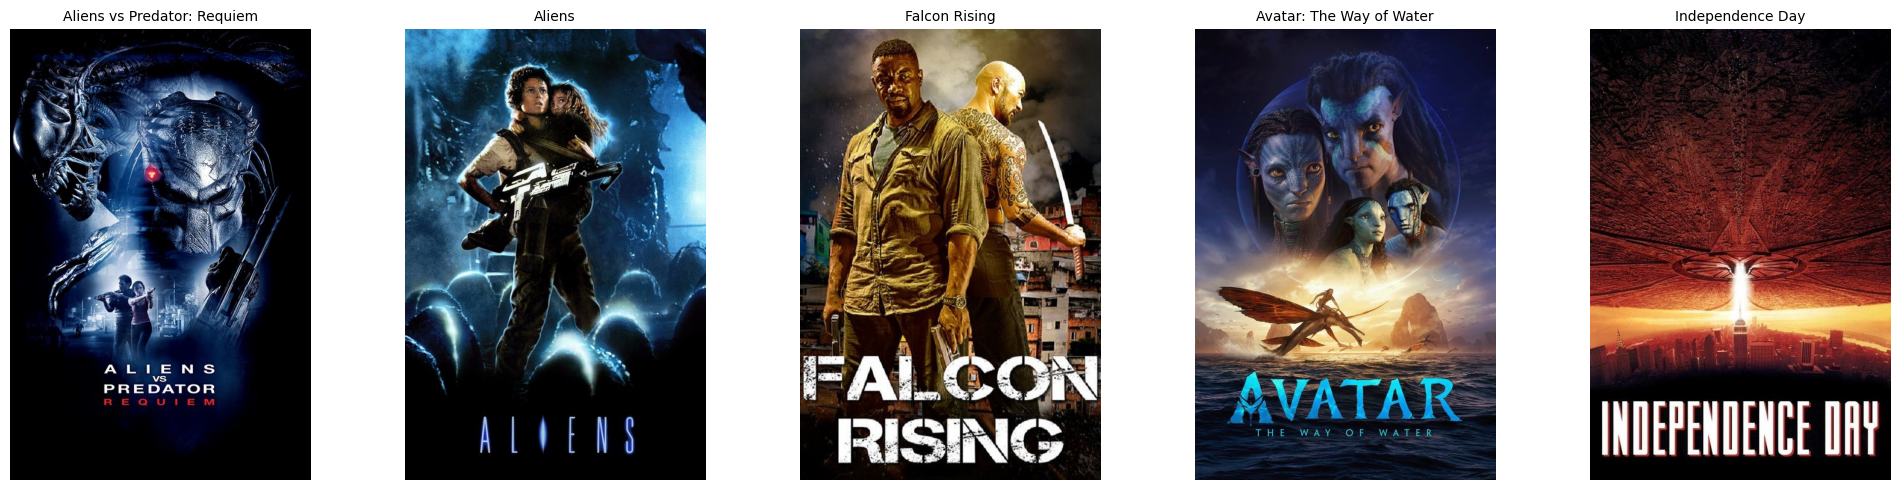

In [44]:
recommend("Avatar")

# Collaborative Filtering

In [45]:
# rename tmdblId to movie_id
ratings.rename(columns={'tmdbId': 'movie_id'}, inplace=True)

# Filter ratings to include only movies present in content-based system

ratings_filtered = ratings[ratings['movie_id'].isin(new_df['movie_id'])]
ratings_filtered = ratings_filtered[['userId', 'movie_id', 'rating']]
ratings_filtered = ratings_filtered.merge(new_df[['movie_id', 'title']], on='movie_id', how='left')
ratings_filtered

,userId,movie_id,rating,title
0,10.0,19995,3.5,Avatar
1,14.0,19995,3.5,Avatar
2,22.0,19995,2.5,Avatar
3,29.0,19995,4.0,Avatar
4,40.0,19995,3.0,Avatar
...,...,...,...,...
24537606,255448.0,1094319,0.5,The Best Man
24537607,114509.0,842544,3.0,Transfusion
24537608,122552.0,842544,4.0,Transfusion
24537609,146355.0,842544,4.0,Transfusion


In [46]:
ratings_filtered.shape

(24537611, 4)

# Sampling the Ratings Dataset
The ratings data set contains over 24 million records, which are computationally challenging to manage, especially while processing them using algorithms like SVD or KNN that involve matrix operations and similarity calculations.

For effective training and testing and yet having a representative set of data, I performed two processes:

**Filtering**
I then deleted the ratings from the list, so that only the movies that exist in our new_df, created while performing content-based filtering, are left. This ensures consistency throughout the recommendation system.

**Sampling**
From the filtered data, I randomly select 40,000 rows using the sample() function. This significantly reduces processing time but still leaves us with a diverse set of user-movie interactions to train and test models on.

This allowed me to balance performance against computation efficiency during model training and testing.


In [47]:
ratings_sample =ratings_filtered[ratings_filtered['movie_id'].isin(new_df['movie_id'])]
ratings_sample = ratings_sample.sample(n=40000, random_state=42)

In [48]:
from surprise import Dataset, Reader, SVD, KNNBasic, KNNWithMeans
from surprise.model_selection import cross_validate

reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(ratings_sample[['userId', 'movie_id', 'rating']], reader)

# models
svd = SVD()
knn_basic = KNNBasic()
knn_means = KNNWithMeans()

# Evaluate all models 
svd_results = cross_validate(svd, data, measures=['RMSE', 'MAE'], cv=3, verbose=True)
knn_basic_results = cross_validate(knn_basic, data, measures=['RMSE', 'MAE'], cv=3, verbose=True)
knn_means_results = cross_validate(knn_means, data, measures=['RMSE', 'MAE'], cv=3, verbose=True)

# Summarize and compare results
results_df = pd.DataFrame({
    'Model': ['SVD', 'KNNBasic', 'KNNWithMeans'],
    'RMSE': [
        svd_results['test_rmse'].mean(),
        knn_basic_results['test_rmse'].mean(),
        knn_means_results['test_rmse'].mean()
    ],
    'MAE': [
        svd_results['test_mae'].mean(),
        knn_basic_results['test_mae'].mean(),
        knn_means_results['test_mae'].mean()
    ]
})

#  results
print("\nModel Evaluation Summary:")
results_df

Evaluating RMSE, MAE of algorithm SVD on 3 split(s).

                  Fold 1  Fold 2  Fold 3  Mean    Std     
RMSE (testset)    0.9932  0.9940  0.9931  0.9934  0.0004  
MAE (testset)     0.7670  0.7647  0.7689  0.7669  0.0018  
Fit time          0.14    0.14    0.14    0.14    0.00    
Test time         0.02    0.02    0.02    0.02    0.00    
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Evaluating RMSE, MAE of algorithm KNNBasic on 3 split(s).

                  Fold 1  Fold 2  Fold 3  Mean    Std     
RMSE (testset)    1.0500  1.0699  1.0462  1.0554  0.0104  
MAE (testset)     0.8336  0.8459  0.8322  0.8372  0.0062  
Fit time          3.27    3.39    3.49    3.38    0.09    
Test time         0.07    0.07    0.07    0.07    0.00    
Computing the msd similarity matrix...
Done computing similarity matrix.
Compu

,Model,RMSE,MAE
0,SVD,0.993429,0.766867
1,KNNBasic,1.055392,0.837237
2,KNNWithMeans,1.103052,0.861874


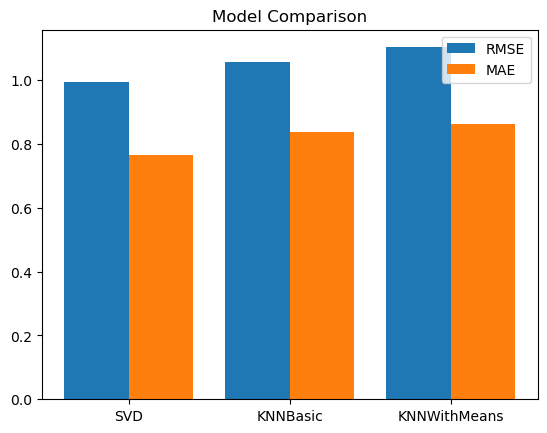

In [49]:
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt

models = ['SVD', 'KNNBasic', 'KNNWithMeans']
rmse = [svd_results['test_rmse'].mean(),
        knn_basic_results['test_rmse'].mean(),
        knn_means_results['test_rmse'].mean()]
mae  = [svd_results['test_mae'].mean(),
        knn_basic_results['test_mae'].mean(),
        knn_means_results['test_mae'].mean()]

x = range(len(models))
plt.bar(x, rmse, width=0.4, label='RMSE', align='center')
plt.bar([i + 0.4 for i in x], mae, width=0.4, label='MAE', align='center')
plt.xticks([i + 0.2 for i in x], models)
plt.legend()
plt.title("Model Comparison")
plt.show()

# Observations:
- SVD performs best in both RMSE and MAE. It generalizes well and fits the rating data more accurately.

- KNN models take longer and perform slightly worse, especially KNNWithMeans.

# Visualize predictions vs. actual 

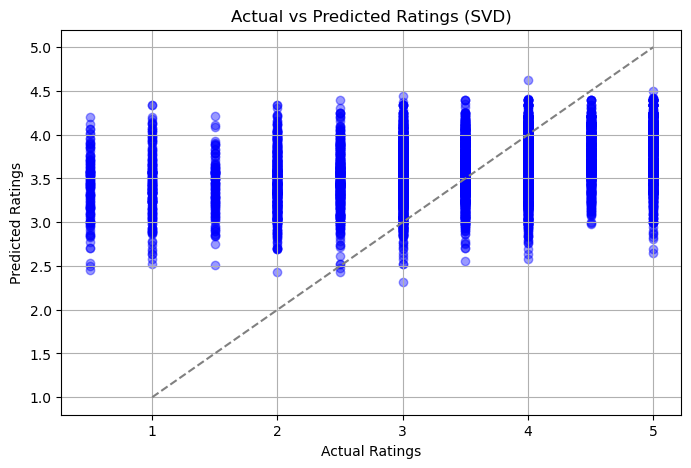

In [50]:
from surprise.model_selection import train_test_split
from surprise import accuracy
import matplotlib.pyplot as plt

# Split data for evaluation
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

# Train SVD
svd_eval = SVD()
svd_eval.fit(trainset)

# Predict ratings on test set
predictions = svd_eval.test(testset)

# Extract actual vs predicted values
actual = [pred.r_ui for pred in predictions]
predicted = [pred.est for pred in predictions]

# Scatter Plot - Actual vs Predicted
plt.figure(figsize=(8,5))
plt.scatter(actual, predicted, alpha=0.4, color='blue')
plt.plot([1, 5], [1, 5], '--', color='gray')  
plt.xlabel('Actual Ratings')
plt.ylabel('Predicted Ratings')
plt.title('Actual vs Predicted Ratings (SVD)')
plt.grid(True)
plt.show()


# Observations:
* Most of the points are close to the diagonal dashed line, representing perfect predictions (i.e., predicted = actual).

* The distribution around the line is moderate, which means that the model predicts fairly but not absolutely accurately.

* For every rating level (1 to 5), predicted ratings cluster between 2.5 and 4.5, which implies:
  - The model is conservative, refraining from extremely high (5.0) or extremely low (1.0) predictions.
  - It possibly underestimates high ratings and overestimates low ones by a bit.

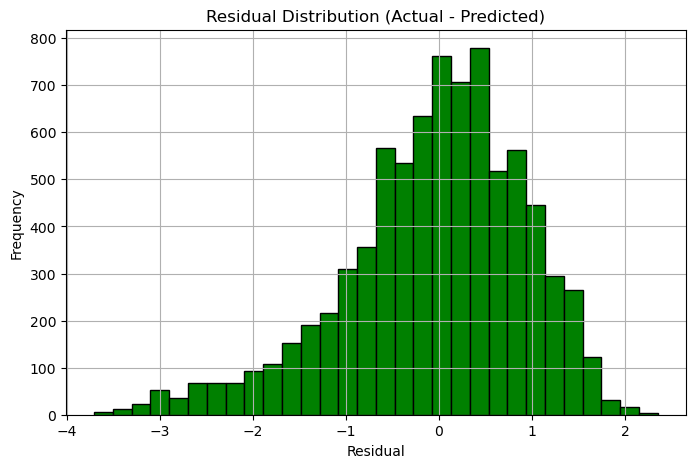

In [51]:
residuals = [a - p for a, p in zip(actual, predicted)]
# Histogram - Residuals
plt.figure(figsize=(8,5))
plt.hist(residuals, bins=30, color='green', edgecolor='black')
plt.title('Residual Distribution (Actual - Predicted)')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


# Observations:
* The distribution is centered around 0, indicating that the model does not have a strong bias towards over or under predicting ratings.

* Most residuals fall within -1.0 and +1.0, indicating that the model predictions are reasonably close to actual values in most cases.

* The distribution is slightly skewed to the left, suggesting that the model may overestimate ratings to some extent in some cases.



# recommendations of Collaborative Filtering

In [52]:
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

def recommend_cf(user_id, svd_model, ratings_df, movies_df, top_n=5):
    if user_id not in ratings_df['userId'].unique():
        print("User ID not found.")
        return

    watched = ratings_df[ratings_df['userId'] == user_id]['movie_id'].tolist()
    all_movies = movies_df['movie_id'].tolist()
    unseen = [m for m in all_movies if m not in watched]

    predictions = [(m, svd_model.predict(user_id, m).est) for m in unseen]
    top_movies = sorted(predictions, key=lambda x: x[1], reverse=True)[:top_n]

    print(f"\nTop {top_n} recommendations for User {user_id}:\n")

    recommended_titles = []
    recommended_ratings = []
    recommended_posters = []

    for movie_id, rating in top_movies:
        title = movies_df[movies_df['movie_id'] == movie_id]['title'].values[0]
        poster_url = fetch_poster(title)

        print(f"{title} (Predicted Rating: {rating:.2f})")

        recommended_titles.append(title)
        recommended_ratings.append(rating)
        recommended_posters.append(poster_url)

    # Display posters
    plt.figure(figsize=(20, 5))
    for i in range(len(recommended_posters)):
        try:
            response = requests.get(recommended_posters[i], timeout=5)
            if response.status_code == 200:
                img = Image.open(BytesIO(response.content))
                plt.subplot(1, top_n, i + 1)
                plt.imshow(img)
                plt.axis('off')
                plt.title(f"{recommended_titles[i]}\nRating {recommended_ratings[i]:.2f}", fontsize=9, wrap=True)
        except Exception:
            pass

    plt.suptitle(f"Top {top_n} Collaborative Filtering Recommendations for User {user_id}", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()



Top 5 recommendations for User 46183:

The Usual Suspects (Predicted Rating: 4.38)
Das Boot (Predicted Rating: 4.37)
The Godfather (Predicted Rating: 4.35)
The Shawshank Redemption (Predicted Rating: 4.34)
Cinema Paradiso (Predicted Rating: 4.31)


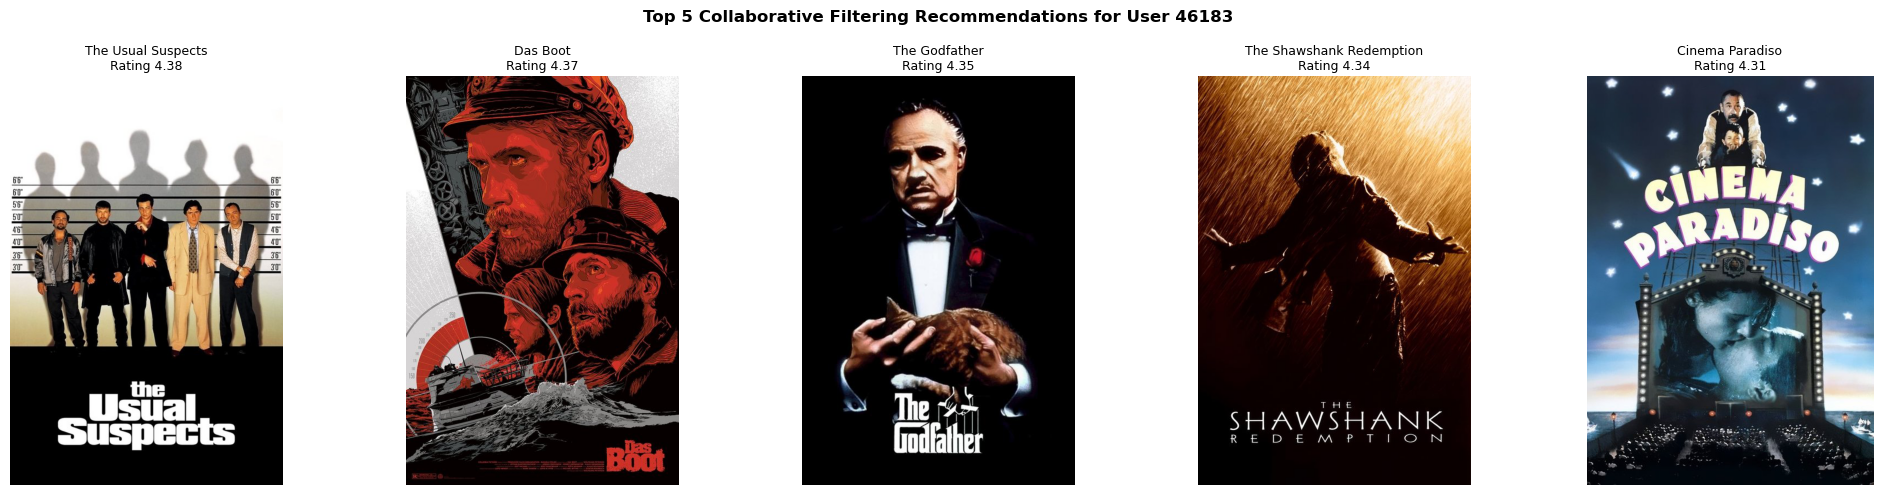

In [53]:
recommend_cf(user_id=46183, svd_model=svd, ratings_df=ratings_sample, movies_df=new_df)

## User Availability Check
Since the dataset is sampled, not all users in the full dataset will be included in the ratings_sample. So, when you are testing collaborative filtering recommendations and Hybrid Recommendation System it's important to ensure that the selected user_id actually exists in the sample.

To check valid user IDs that exist in the sample,  use:

In [54]:
print(ratings_sample['userId'].unique()[:100])

[232193. 309944. 106164.  46183. 234998.  16453. 201918. 264645. 188309.
 283585.  15175. 299686.  28385. 162413. 167942. 137547. 283842.  49409.
 278070.   1184.    691.  90535. 244166. 323041.  89162.  64537. 223394.
  40442. 153604. 303976. 106202. 176361. 188108.   7991. 112437. 254732.
 141725.  45322.  91569.  76411. 250617. 277813. 326938. 282259.  29724.
 306232. 177877. 263365.  63644.  85836. 202439.  74656. 239354. 227607.
   8749. 157621. 132493. 292094. 234473. 183122. 325324.  35015. 179821.
 128795. 320078. 126581.  35597. 323803. 288398. 107272. 168192. 297962.
  15200. 112078. 204138. 123027. 215852.  85219.  70007. 314899. 148237.
 274552. 304271. 277645.  45433. 111652.  27928. 239948. 171140. 254550.
 154713. 187188. 199183. 156917. 194226. 188609.  32775.  70867.  64981.
   2558.]


# Hybrid Recommendation System 
This system will combine:

- Content-Based Filtering (using cosine similarity on tags)

- Collaborative Filtering (using predicted ratings from SVD)



In [55]:
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

def hybrid_recommend(user_id, movie_title, svd_model, new_df, ratings_df, similarity_matrix, top_n=5, alpha=0.4):
    movie_title = movie_title.lower()

    if movie_title not in new_df['title'].str.lower().values:
        print("Movie not found in the dataset.")
        return

    if user_id not in ratings_df['userId'].unique():
        print("User ID not found.")
        return

    # Content-Based Scores 
    index = new_df[new_df['title'].str.lower() == movie_title].index[0]
    cb_scores = list(enumerate(similarity_matrix[index]))
    cb_scores = {i: score for i, score in cb_scores}

    # Collaborative Filtering Scores 
    watched = ratings_df[ratings_df['userId'] == user_id]['movie_id'].tolist()
    all_movies = new_df['movie_id'].tolist()
    unseen = [m for m in all_movies if m not in watched]

    cf_scores = {}
    for movie_id in unseen:
        pred = svd_model.predict(user_id, movie_id).est
        cf_scores[movie_id] = pred

    # Normalize CF scores to [0, 1]
    if cf_scores:
        min_cf = min(cf_scores.values())
        max_cf = max(cf_scores.values())
        cf_range = max_cf - min_cf if max_cf != min_cf else 1
        cf_scores_norm = {k: (v - min_cf) / cf_range for k, v in cf_scores.items()}
    else:
        cf_scores_norm = {}

    #  Hybrid Scores 
    hybrid_scores = []
    for idx, row in new_df.iterrows():
        movie_id = row['movie_id']
        if movie_id in watched:
            continue

        cb = cb_scores.get(idx, 0)
        cf = cf_scores_norm.get(movie_id, 0)
        hybrid = alpha * cb + (1 - alpha) * cf
        hybrid_scores.append((idx, movie_id, hybrid))

    seed_index = new_df[new_df['title'].str.lower() == movie_title].index[0]
    hybrid_scores = [
        (idx, movie_id, score)
        for idx, movie_id, score in hybrid_scores
        if idx != seed_index
    ]

    top_movies = sorted(hybrid_scores, key=lambda x: x[2], reverse=True)[:top_n]

    # Collect Info 
    recommended_titles = []
    recommended_scores = []
    recommended_posters = []

    print(f"\nTop {top_n} Hybrid Recommendations for User {user_id} based on '{movie_title.title()}':\n")
    for idx, movie_id, score in top_movies:
        title = new_df.loc[idx, 'title']
        poster_url = fetch_poster(title)

        print(f"{title}  (Hybrid Score: {score:.4f})")

        recommended_titles.append(title)
        recommended_scores.append(score)
        recommended_posters.append(poster_url)

    #  Display Posters 
    plt.figure(figsize=(20, 5))
    for i in range(len(recommended_posters)):
        try:
            response = requests.get(recommended_posters[i], timeout=5)
            if response.status_code == 200:
                img = Image.open(BytesIO(response.content))
                plt.subplot(1, top_n, i + 1)
                plt.imshow(img)
                plt.axis('off')
                plt.title(
                    f"{recommended_titles[i]}\nScore {recommended_scores[i]:.4f}",
                    fontsize=9,
                    wrap=True
                )
        except Exception:
            pass

    plt.suptitle(
        f"Top {top_n} Hybrid Recommendations for User {user_id} | Based on: '{movie_title.title()}'",
        fontsize=12,
        fontweight='bold'
    )
    plt.tight_layout()
    plt.show()



Top 5 Hybrid Recommendations for User 46183 based on 'Avatar':

The Godfather  (Hybrid Score: 0.6017)
The Usual Suspects  (Hybrid Score: 0.6000)
Taxi Driver  (Hybrid Score: 0.5980)
Das Boot  (Hybrid Score: 0.5976)
To Kill a Mockingbird  (Hybrid Score: 0.5869)


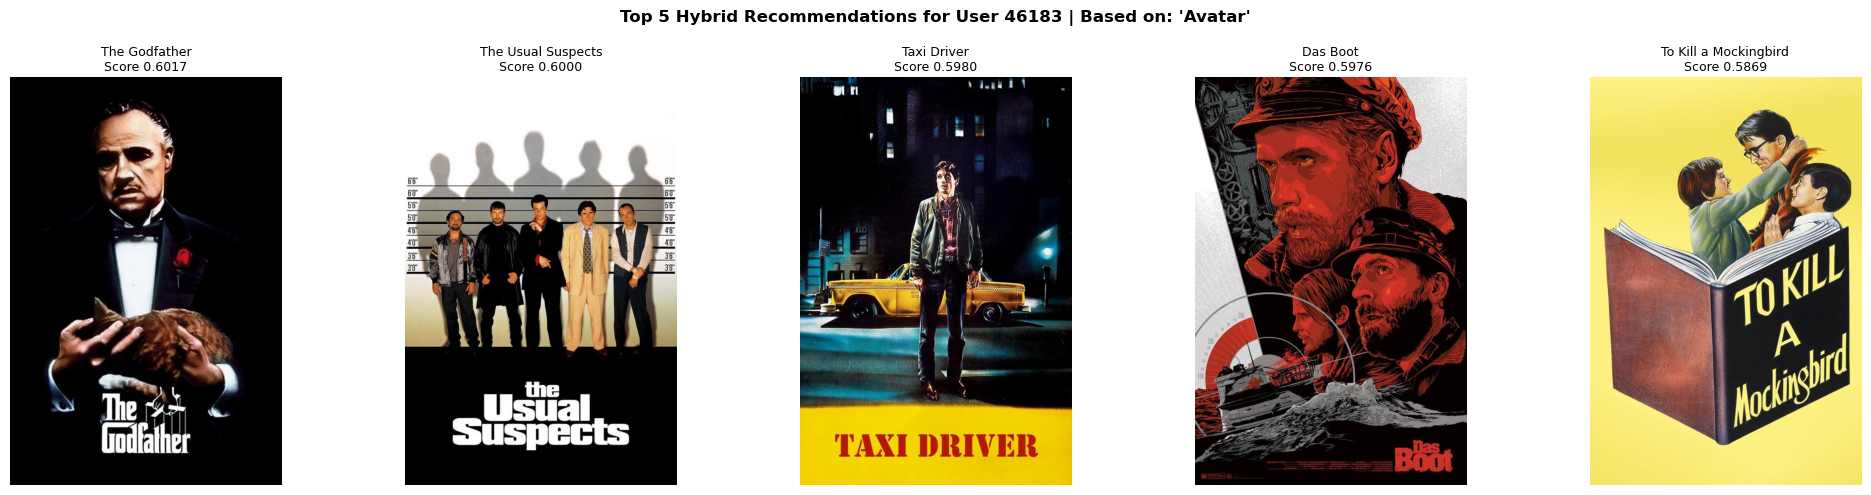

In [56]:
hybrid_recommend(
    user_id=46183,
    movie_title="Avatar",
    svd_model=svd,
    new_df=new_df,
    ratings_df=ratings_sample,
    similarity_matrix=similarity,
    top_n=5,
    alpha=0.4)

### Handling Large Ratings Dataset

The original ratings dataset contains over 24 million records, which is too large to load and process efficiently within limited system memory or execution time (especially during model training and evaluation).

To address this, I selected a **random sample of 40,000 ratings** using:

```python
ratings_sample =ratings_filtered[ratings_filtered['movie_id'].isin(new_df['movie_id'])]
ratings_sample = ratings_sample.sample(n=40000, random_state=42)
```

## User Availability Check
Since the dataset is sampled, not all users in the full dataset will be included in the ratings_sample. So, when you are testing collaborative filtering recommendations and Hybrid Recommendation System it's important to ensure that the selected user_id actually exists in the sample.

To check valid user IDs that exist in the sample,  use:

In [57]:
print(ratings_sample['userId'].unique()[:100])

[232193. 309944. 106164.  46183. 234998.  16453. 201918. 264645. 188309.
 283585.  15175. 299686.  28385. 162413. 167942. 137547. 283842.  49409.
 278070.   1184.    691.  90535. 244166. 323041.  89162.  64537. 223394.
  40442. 153604. 303976. 106202. 176361. 188108.   7991. 112437. 254732.
 141725.  45322.  91569.  76411. 250617. 277813. 326938. 282259.  29724.
 306232. 177877. 263365.  63644.  85836. 202439.  74656. 239354. 227607.
   8749. 157621. 132493. 292094. 234473. 183122. 325324.  35015. 179821.
 128795. 320078. 126581.  35597. 323803. 288398. 107272. 168192. 297962.
  15200. 112078. 204138. 123027. 215852.  85219.  70007. 314899. 148237.
 274552. 304271. 277645.  45433. 111652.  27928. 239948. 171140. 254550.
 154713. 187188. 199183. 156917. 194226. 188609.  32775.  70867.  64981.
   2558.]


# Project Summary
The aim of this project was to implement a personalized movie recommendation system on the basis of three significant techniques:

**Content-Based Filtering:**

It was on the basis of metadata of films such as overview, genres, keywords, cast, and crew. They were combined into a single column of tags, vectorized with CountVectorizer  and compared with cosine similarity. The closest movies were recommended

**Collaborative Filtering:**

As the first set of ratings was extremely huge (more than 24 million rows), a sample size of 50,000 ratings was used. Surprise library was used to train and test models such as SVD, KNNBasic and KNNWithMeans. RMSE and MAE were compared on the performance basis. Bar chart and residual plots were used for result visualization.

**Hybrid Recommendation System:**

This method combined the benefits of content similarity and collaborative predictions. It calculated a weighted hybrid score by the following formula:
`Hybrid Score = α * Content_Similarity + (1 – α) * Predicted_Rating`
This provided a balance between metadata based and user preference based recommendations. The value of alpha varied according to different scenarios.



# Conclusion and Future Work
The project successfully executed the implementation of three recommendation systems and compared their performance. Fast and efficient metadata-based recommendations were achieved through content-based filtering. Collaborative filtering (SVD) generated more personalized recommendations and the best values for RMSE and MAE. Hybrid model introduced flexibility based on both approaches.

**Limitations:**
- The entire rating dataset was not used due to memory and run-time constraints.

- New users or movies (cold start) are still a problem for collaborative filtering.

- Runtime was significant during model training and evaluation.

**Potential future enhancements are:**

- Training on a larger dataset with distributed computing libraries (e.g., Dask or Apache Spark).

- Applying deep learning models such as Neural Collaborative Filtering or BERT-based content models.

- Building a user interface with Streamlit or deploying as a web application with Flask.

- Including real-time user feedback to further customize recommendations.

This framework allows for a highly scalable and sound foundation for practical recommendation systems.